In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# -*- coding: utf-8 -*-
"""
Context-Aware Quantum-Inspired Intelligence for AI-Aided Cyber Worm Detection
Simulation (Preliminary)

This Jupyter Notebook provides a simplified simulation of the proposed methodology.
It includes:
    1. Generation of synthetic network traffic and contextual data.
    2. Implementation of a simplified Quantum-Inspired Particle Swarm Optimization (QPSO)
       for feature selection.
    3. Training of a Variational Autoencoder (VAE) for anomaly detection.
    4. Basic context-aware threat analysis.

Note: This is a highly simplified simulation and does not fully represent the complexity
of real-world military networks or sophisticated AI-aided cyber worms. It serves as a
proof-of-concept for the core ideas.
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
# Seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# --- 1. Load and Preprocess Custom Dataset ---
csv_file_path = '/content/drive/MyDrive/conquest/conquest_benign_anomaly_data.csv'  # Replace with the actual path to your CSV file

try:
    df = pd.read_csv(csv_file_path)
    print(f"Dataset loaded successfully from {csv_file_path}")
except FileNotFoundError:
    print(f"Error: CSV file not found at {csv_file_path}")
    exit()

Dataset loaded successfully from /content/drive/MyDrive/conquest/conquest_benign_anomaly_data.csv


In [ ]:
# Identify the label column (assuming it's named 'label')
label_column = 'binary_label'
if label_column not in df.columns:
    print(f"Error: Label column '{label_column}' not found in the dataset.")
    exit()

labels = df[label_column].values
data = df.drop(columns=[label_column])

# Convert all non-numeric columns to numeric
for column in data.columns:
    if pd.api.types.is_object_dtype(data[column]):
        try:
            # Try converting directly to float (if they are string representations of numbers)
            data[column] = pd.to_numeric(data[column], errors='raise')
        except ValueError:
            print(f"Converting non-numeric column: {column}")
            # Apply Label Encoding as a simple conversion for other strings
            le = LabelEncoder()
            data[column] = le.fit_transform(data[column])
    elif not pd.api.types.is_numeric_dtype(data[column]):
        print(f"Warning: Column '{column}' is not numeric and not string. Handling may be needed.")

Converting non-numeric column: srcip
Converting non-numeric column: dstip
Converting non-numeric column: protocol_m
Converting non-numeric column: payload


In [ ]:
print(data.isna().sum())

srcip         0
sport         0
dstip         0
dsport        0
protocol_m    0
sttl          0
total_len     0
payload       0
stime         0
dtype: int64


In [ ]:
# Separate network and context features (you might need to adjust these based on your dataset)
# Assuming the first few columns are network features and the rest are context
n_network_features = 7  # Adjust based on your dataset
network_data = data.iloc[:, :n_network_features].values
context_data = data.iloc[:, n_network_features:].values


In [ ]:
# Scale the combined data
scaler = StandardScaler()
augmented_data_scaled = scaler.fit_transform(np.hstack((network_data, context_data)))


In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(augmented_data_scaled, labels, test_size=0.2, random_state=42)
X_train_normal = X_train[y_train == 0]
X_test_normal = X_test[y_test == 0]
X_test_anomalous = X_test[y_test == 1]

In [ ]:
# --- 2. Simplified Quantum-Inspired Feature Selection (Illustrative) ---
def simple_fitness_evaluation(feature_indices, data, labels):
    """
    A very basic fitness function (not a true QPSO implementation).
    It calculates the variance of anomalous samples compared to normal samples
    for the selected features. Higher variance might indicate better separability.
    """
    if not feature_indices:
        return 0
    normal_data = data[labels == 0][:, feature_indices]
    anomalous_data = data[labels == 1][:, feature_indices]
    if normal_data.size == 0 or anomalous_data.size == 0:
        return 0
    return np.var(anomalous_data) / (np.var(normal_data) + 1e-6)

In [ ]:
# Let's evaluate the fitness of all features
all_feature_indices = list(range(augmented_data_scaled.shape[1]))
fitness_all = simple_fitness_evaluation(all_feature_indices, augmented_data_scaled, labels)
print(f"Fitness using all features (illustrative): {fitness_all:.4f}")


Fitness using all features (illustrative): 0.7855


In [ ]:
# For simplicity, we proceed with all features.
selected_feature_indices = all_feature_indices

In [ ]:
# Prepare training data with selected features
X_train_selected = X_train_normal[:, selected_feature_indices]
X_test_selected = X_test[:, selected_feature_indices]

In [ ]:
# --- 3. Variational Autoencoder (VAE) for Anomaly Detection (using SGD) ---
latent_dim = 7
input_shape = (X_train_selected.shape[1],)  # Now a tuple (9,)

class VAE(keras.Model):
    def __init__(self, latent_dim, input_shape):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = keras.Sequential(
            [
                layers.Input(shape=input_shape),
                layers.Dense(32, activation="relu"),
                layers.Dense(16, activation="relu"),
                layers.Dense(latent_dim * 2),  # Mean and log(variance)
            ]
        )
        self.decoder = keras.Sequential(
            [
                layers.Input(shape=(latent_dim,)),  # Change here: (latent_dim,)
                layers.Dense(16, activation="relu"),
                layers.Dense(32, activation="relu"),
                layers.Dense(input_shape[0], activation="sigmoid"), # Use sigmoid for scaled data (0 to 1)
            ]
        )
    # ... (rest of the VAE class code remains unchanged)

    def sample(self, eps=None):
        if eps is None:
            eps = tf.random.normal(shape=(tf.shape(self.z_mean)[0], self.latent_dim))
        return self.z_mean + tf.exp(0.5 * self.z_log_var) * eps

    def encode(self, inputs):
        self.z_mean, self.z_log_var = tf.split(self.encoder(inputs), num_or_size_splits=2, axis=1)
        return self.z_mean, self.z_log_var

    def decode(self, z):
        return self.decoder(z)

    def call(self, inputs):
        self.z_mean, self.z_log_var = self.encode(inputs)
        z = self.sample()
        return self.decode(z)

# Instantiate and compile the VAE
vae = VAE(latent_dim, input_shape)
optimizer = keras.optimizers.SGD(learning_rate=0.001) # Using Stochastic Gradient Descent

def log_normal_pdf(sample, mean, logvar, raxis=1):
    log2pi = tf.math.log(2.0 * np.pi)
    return tf.reduce_sum(
        -0.5 * ((sample - mean) ** 2.0 * tf.exp(-logvar) + logvar + log2pi), axis=raxis
    )

@tf.function
def train_step(model, x):
    """Executes one training step and returns the loss."""
    with tf.GradientTape() as tape:
        z_mean, z_log_var = model.encode(x)
        z = model.sample()
        reconstruction = model.decode(z)
        reconstruction_loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(x, reconstruction)
        )
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss, reconstruction_loss, kl_loss

epochs = 11
batch_size = 64
train_dataset = tf.data.Dataset.from_tensor_slices(X_train_selected).batch(batch_size)

for epoch in range(1, epochs + 1):
    total_loss_avg = tf.keras.metrics.Mean()
    recon_loss_avg = tf.keras.metrics.Mean()
    kl_loss_avg = tf.keras.metrics.Mean()
    for x_batch in train_dataset:
        total_loss, recon_loss, kl_loss = train_step(vae, x_batch)
        total_loss_avg.update_state(total_loss)
        recon_loss_avg.update_state(recon_loss)
        kl_loss_avg.update_state(kl_loss)
    print(f"Epoch {epoch}, Total Loss: {total_loss_avg.result():.4f}, "
          f"Reconstruction Loss: {recon_loss_avg.result():.4f}, "
          f"KL Loss: {kl_loss_avg.result():.4f}")


Epoch 1, Total Loss: 0.8748, Reconstruction Loss: 0.6548, KL Loss: 0.2201
Epoch 2, Total Loss: 0.5798, Reconstruction Loss: 0.5476, KL Loss: 0.0321
Epoch 3, Total Loss: 0.4648, Reconstruction Loss: 0.4425, KL Loss: 0.0223
Epoch 4, Total Loss: 0.3431, Reconstruction Loss: 0.3231, KL Loss: 0.0200
Epoch 5, Total Loss: 0.1997, Reconstruction Loss: 0.1797, KL Loss: 0.0200
Epoch 6, Total Loss: 0.0197, Reconstruction Loss: -0.0022, KL Loss: 0.0220
Epoch 7, Total Loss: -0.2080, Reconstruction Loss: -0.2348, KL Loss: 0.0268
Epoch 8, Total Loss: -0.5101, Reconstruction Loss: -0.5465, KL Loss: 0.0363
Epoch 9, Total Loss: -0.9286, Reconstruction Loss: -0.9839, KL Loss: 0.0553
Epoch 10, Total Loss: -1.5858, Reconstruction Loss: -1.6817, KL Loss: 0.0959
Epoch 11, Total Loss: -2.8736, Reconstruction Loss: -3.0767, KL Loss: 0.2030


In [ ]:
# Anomaly Detection using Reconstruction Error
def calculate_reconstruction_error(model, data):
    reconstructions = model.predict(data)
    mse = np.mean(np.square(data - reconstructions), axis=1)
    return mse

normal_recon_errors_train = calculate_reconstruction_error(vae, X_train_selected)
normal_recon_errors_test = calculate_reconstruction_error(vae, X_test_normal)
anomalous_recon_errors_test = calculate_reconstruction_error(vae, X_test_anomalous)

# Determine a threshold (e.g., based on the distribution of normal reconstruction errors)
threshold = np.percentile(normal_recon_errors_train, 2)
print(f"Anomaly detection threshold: {threshold:.4f}")

742/742 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
3763/3763 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Anomaly detection threshold: 0.5883


In [ ]:
# Predict anomalies on the test set
test_recon_errors = calculate_reconstruction_error(vae, X_test_selected)
y_pred_vae_scores = test_recon_errors # Keep the scores for ROC and thresholding
y_pred_vae = (y_pred_vae_scores > threshold).astype(int)

# Evaluate VAE performance
#auc_vae = roc_auc_score(y_test, test_recon_errors)
#print(f"VAE AUC on test set: {auc_vae:.4f}")

#fpr_vae, tpr_vae, thresholds_vae = roc_curve(y_test, test_recon_errors)


3947/3947 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [ ]:
# --- 4. Context-Aware Threat Analysis (Simplified) ---
def context_aware_risk_assessment(anomaly_scores, context_data_test, threshold_multiplier=1.0):
    risk_scores = np.zeros_like(anomaly_scores)
    for i in range(len(anomaly_scores)):
        risk = anomaly_scores[i]
        if context_data_test[i, 0] > np.mean(context_data_test[:, 0]) + np.std(context_data_test[:, 0]):
            risk *= threshold_multiplier * 1.5
        risk_scores[i] = risk
    return risk_scores

n_train = int(len(data) * 0.8)
context_data_test = context_data[n_train:]

risk_scores = context_aware_risk_assessment(test_recon_errors, context_data_test)
y_pred_context_aware = (risk_scores > threshold).astype(int)

In [ ]:
# --- 5. Evaluation Metrics and Visualization ---

# Evaluate VAE performance (without context-awareness for direct VAE evaluation)
accuracy_vae = accuracy_score(y_test, y_pred_vae)
recall_vae = recall_score(y_test, y_pred_vae)
precision_vae = precision_score(y_test, y_pred_vae)
f1_vae = f1_score(y_test, y_pred_vae)
conf_matrix_vae = confusion_matrix(y_test, y_pred_vae)

In [ ]:
print("\n--- VAE Performance (without Context-Awareness) ---")
print(f"Accuracy: {accuracy_vae:.4f}")
print(f"Recall: {recall_vae:.4f}")
print(f"Precision: {precision_vae:.4f}")
print(f"F1-Score: {f1_vae:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_vae)


--- VAE Performance (without Context-Awareness) ---
Accuracy: 0.9520
Recall: 0.9977
Precision: 0.9541
F1-Score: 0.9754

Confusion Matrix:
[[   109   5782]
 [   275 120132]]


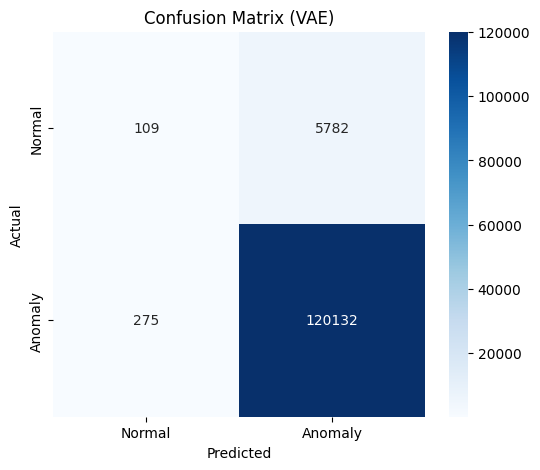

In [ ]:
# Plot Confusion Matrix for VAE
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_vae, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (VAE)')
plt.show()

In [ ]:
# Evaluate Context-Aware performance
accuracy_ca = accuracy_score(y_test, y_pred_context_aware)
recall_ca = recall_score(y_test, y_pred_context_aware)
precision_ca = precision_score(y_test, y_pred_context_aware)
f1_ca = f1_score(y_test, y_pred_context_aware)
conf_matrix_ca = confusion_matrix(y_test, y_pred_context_aware)

In [ ]:
print("\n--- Context-Aware VAE Performance ---")
print(f"Accuracy: {accuracy_ca:.4f}")
print(f"Recall: {recall_ca:.4f}")
print(f"Precision: {precision_ca:.4f}")
print(f"F1-Score: {f1_ca:.4f}")
print("\nConfusion Matrix (Context-Aware):")
print(conf_matrix_ca)


--- Context-Aware VAE Performance ---
Accuracy: 0.9524
Recall: 0.9982
Precision: 0.9540
F1-Score: 0.9756

Confusion Matrix (Context-Aware):
[[    91   5800]
 [   218 120189]]


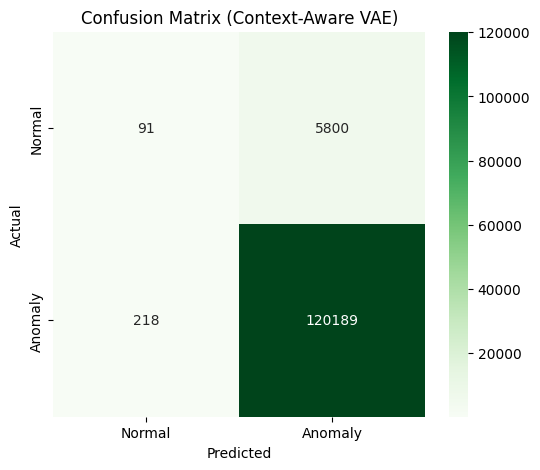

In [ ]:
# Plot Confusion Matrix for Context-Aware
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_ca, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Context-Aware VAE)')
plt.show()

In [ ]:
# ROC Curve (as before)
auc_vae = roc_auc_score(y_test, y_pred_vae_scores)
fpr_vae, tpr_vae, thresholds_vae = roc_curve(y_test, y_pred_vae_scores)

risk_scores_auc = context_aware_risk_assessment(y_pred_vae_scores, context_data_test)
auc_context_aware = roc_auc_score(y_test, risk_scores_auc)
fpr_ca, tpr_ca, thresholds_ca = roc_curve(y_test, risk_scores_auc)

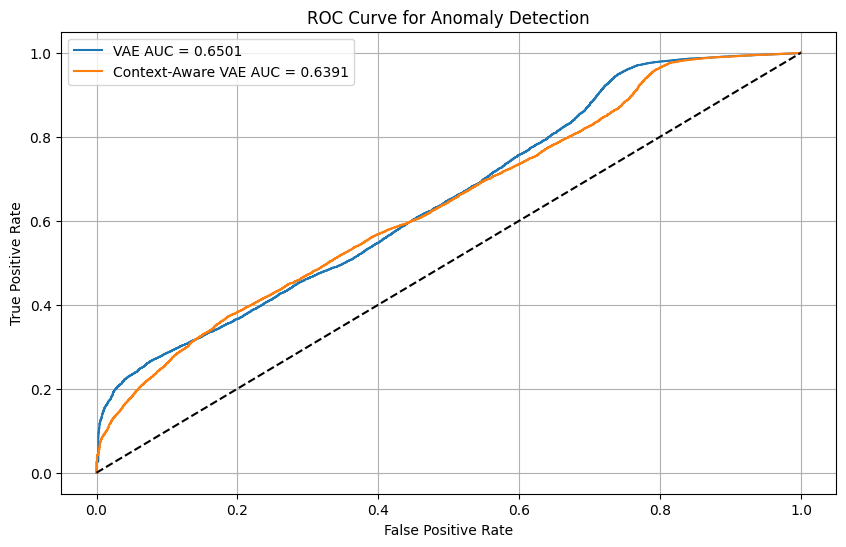


Simplified simulation with custom dataset and SGD completed.


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_vae, tpr_vae, label=f'VAE AUC = {auc_vae:.4f}')
plt.plot(fpr_ca, tpr_ca, label=f'Context-Aware VAE AUC = {auc_context_aware:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Anomaly Detection')
plt.legend()
plt.grid(True)
plt.show()

print("\nSimplified simulation with custom dataset and SGD completed.")

In [ ]:
# Get the context data for the test set
n_train = int(len(data) * 0.8) # Assuming 80% train split
context_data_test = context_data[n_train:]

In [ ]:
# Apply context-aware risk assessment
risk_scores = context_aware_risk_assessment(test_recon_errors, context_data_test)
y_pred_context_aware = (risk_scores > threshold).astype(int)
auc_context_aware = roc_auc_score(y_test, risk_scores)
print(f"Context-Aware AUC on test set: {auc_context_aware:.4f}")

fpr_ca, tpr_ca, thresholds_ca = roc_curve(y_test, risk_scores)

Context-Aware AUC on test set: 0.3991


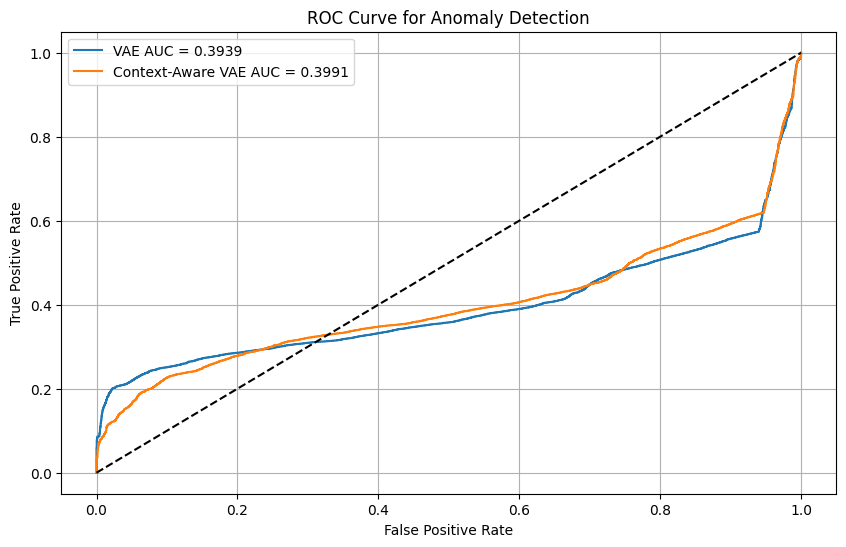


Simplified simulation with custom dataset completed.


In [ ]:
# --- 5. Results Visualization ---
plt.figure(figsize=(10, 6))
plt.plot(fpr_vae, tpr_vae, label=f'VAE AUC = {auc_vae:.4f}')
plt.plot(fpr_ca, tpr_ca, label=f'Context-Aware VAE AUC = {auc_context_aware:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Anomaly Detection')
plt.legend()
plt.grid(True)
plt.show()

print("\nSimplified simulation with custom dataset completed.")

**USING LSTM FOR MULTICLASS PREDICTION**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# -*- coding: utf-8 -*-
"""
Multiclass Prediction using LSTM with Custom CSV Dataset

This Jupyter Notebook demonstrates multiclass prediction using an LSTM model
with data loaded from a CSV file. The target column is assumed to have
more than 2 unique classes.

Assumptions about the CSV file:
    - It contains sequential data suitable for LSTM (e.g., time series).
    - One column is the 'target' column with more than 2 unique classes.
    - Non-numeric columns will be converted to numeric.
    - Data might need preprocessing for sequence learning (e.g., padding).
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
# Seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
# --- 1. Load and Preprocess Custom Dataset ---
csv_file_path = '/content/drive/MyDrive/conquest-milcom/ACI-IoT-2023.csv'  # Replace with the actual path

try:
    df = pd.read_csv(csv_file_path)
    print(f"Dataset loaded successfully from {csv_file_path}")
except FileNotFoundError:
    print(f"Error: CSV file not found at {csv_file_path}")
    exit()

Dataset loaded successfully from /content/drive/MyDrive/conquest-milcom/ACI-IoT-2023.csv


In [5]:
df_dropped = df.drop('Connection Type', axis=1)

In [6]:
print(df_dropped.head())

# To get some basic information about the DataFrame:
print(df_dropped.info())

# To see descriptive statistics:
print(df_dropped.describe())

                                 Flow ID        Src IP  Src Port  \
0  192.168.1.7-54.230.163.60-33344-443-6   192.168.1.7     33344   
1    192.168.3.6-91.189.91.48-36754-80-6   192.168.3.6     36754   
2    192.168.3.6-91.189.91.48-36754-80-6   192.168.3.6     36754   
3   192.168.1.9-192.168.1.1-8080-40426-6   192.168.1.9      8080   
4  192.168.1.20-35.232.111.17-40054-80-6  192.168.1.20     40054   

          Dst IP  Dst Port  Protocol            Timestamp  Flow Duration  \
0  54.230.163.60       443         6  2023-01-11 09:43:40         379933   
1   91.189.91.48        80         6  2023-01-11 09:43:51         205637   
2   91.189.91.48        80         6  2023-01-11 09:43:51              0   
3    192.168.1.1     40426         6  2023-01-11 09:43:49        5030379   
4  35.232.111.17        80         6  2023-01-11 09:43:56          72278   

   Total Fwd Packet  Total Bwd packets  ...  Fwd Seg Size Min  Active Mean  \
0                11                 11  ...             

In [7]:
# Identify the target column
target_column = 'Label'
if target_column not in df_dropped.columns:
    print(f"Error: Target column '{target_column}' not found.")
    exit()

y_original = df_dropped[target_column].values
X = df_dropped.drop(columns=[target_column])

In [10]:
y_original

array(['Benign', 'Benign', 'Benign', ..., 'Benign', 'Benign', 'Benign'],
      dtype=object)

In [12]:
# Count the unique values in the target column
value_counts = df_dropped['Label'].value_counts()
value_counts

,count
Label,
Port Scan,441282
Benign,329295
ICMP Flood,225234
Ping Sweep,71928
DNS Flood,46935
Vulnerability Scan,39537
OS Scan,37524
Slowloris,18643
SYN Flood,13857


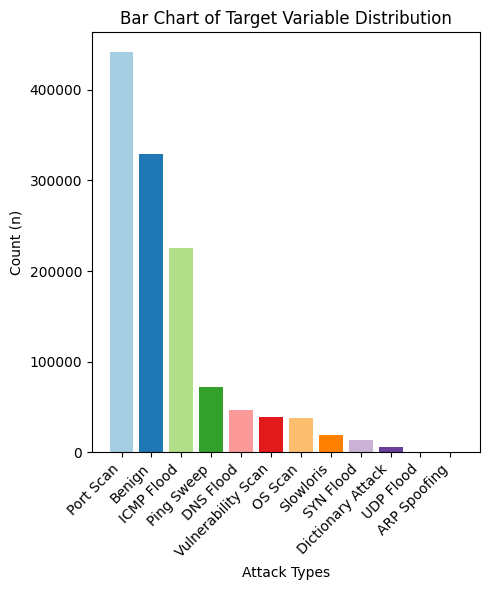

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each unique value in the target column
value_counts = df_dropped['Label'].value_counts()
title ='Bar Chart of Target Variable Distribution'

# Get the unique values (labels) and their counts (heights)
unique_values = value_counts.index
counts = value_counts.values

# Generate a list of distinct colors for each unique value
num_unique = len(unique_values)
colors = sns.color_palette('Paired', n_colors=num_unique) # You can choose other palettes like 'Set2', 'Paired', etc.

# Create the bar chart using seaborn
plt.figure(figsize=(5, 6))  # Adjust figure size as needed
#sns.barplot(x=value_counts.index, y=value_counts.values)
plt.bar(unique_values, counts, color=colors)

# Add labels and title
plt.xlabel('Attack Types')
plt.ylabel('Count (n)')
plt.title(title)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping

# Display the plot
plt.show()

In [14]:
# Convert all non-numeric columns to numeric
for column in X.columns:
    if pd.api.types.is_object_dtype(X[column]):
        try:
            X[column] = pd.to_numeric(X[column], errors='raise')
        except ValueError:
            print(f"Converting non-numeric column: {column}")
            le = LabelEncoder()
            X[column] = le.fit_transform(X[column])
    elif not pd.api.types.is_numeric_dtype(X[column]):
        print(f"Warning: Column '{column}' is not numeric and not string. Handling needed.")

X = X.values  # Convert features to numpy array

Converting non-numeric column: Flow ID
Converting non-numeric column: Src IP
Converting non-numeric column: Dst IP
Converting non-numeric column: Timestamp


In [15]:
# --- 2. Prepare Data for LSTM ---
# Assuming your data is already in a sequential format or can be reshaped.
# LSTM expects input in the shape (samples, time steps, features).

# Determine the number of unique classes in the target variable
unique_classes = np.unique(y_original)
num_classes = len(unique_classes)
print(f"Number of unique classes in the target: {num_classes}")

Number of unique classes in the target: 12


In [16]:
# Encode the target variable to numerical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_original)

In [17]:
# Convert integer labels to one-hot encoded vectors
y_categorical = to_categorical(y_encoded, num_classes=num_classes)

In [18]:
# Reshape input data for LSTM if it's not already sequential
# Example: If each row is a time step and you have multiple features
n_samples = X.shape[0]
n_features = X.shape[1]
n_time_steps = 1  # Assuming each row is one time step
X_reshaped = X.reshape(n_samples, n_time_steps, n_features)

In [19]:
# Split data into training and testing sets
X_train, X_test, y_train_cat, y_test_cat, y_train_encoded, y_test_encoded, y_train_original, y_test_original = train_test_split(
    X_reshaped, y_categorical, y_encoded, y_original, test_size=0.2, random_state=42
)

In [24]:
# Scale the input features
scaler = StandardScaler()
# Replace infinite or very large values with NaN
X_train_no_inf = np.nan_to_num(X_train.reshape(-1, n_features))
# Impute NaN values with the mean of the column
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_no_inf)

# Reshape BEFORE scaling to maintain compatibility with LSTM input shape
# Instead of reshaping back to the original shape of X_train,
# reshape to match the shape of X_train_imputed, which has 81 features:
X_train_reshaped_2d = X_train_imputed.reshape(-1, X_train_imputed.shape[1])  # Reshape to 2D for scaling
X_train_scaled = scaler.fit_transform(X_train_reshaped_2d)  # Scale the data
X_train_scaled = X_train_scaled.reshape(X_train_imputed.shape[0], 1, X_train_imputed.shape[1]) # Reshape using imputed shape


# Apply the same preprocessing to X_test
X_test_no_inf = np.nan_to_num(X_test.reshape(-1, n_features))
X_test_imputed = imputer.transform(X_test_no_inf) # Use the same imputer fitted on training data

# Reshape X_test_imputed to 2D before scaling:
X_test_reshaped_2d = X_test_imputed.reshape(-1, X_test_imputed.shape[1])  # Reshape to 2D for scaling
X_test_scaled = scaler.transform(X_test_reshaped_2d)  # Scale the data
# Reshape using imputed shape:
X_test_scaled = X_test_scaled.reshape(X_test_imputed.shape[0], 1, X_test_imputed.shape[1])

/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [20 21]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [20 21]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [27]:
# --- 3. Build and Train the LSTM Model ---
# Update the input_shape to match X_train_scaled
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])))  # input_shape=(1, 81)
model.add(Dense(num_classes, activation='softmax'))  # Softmax for multiclass

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

epochs = 50
batch_size = 32

history = model.fit(X_train_scaled, y_train_cat, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        37,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,156 (149.05 KB)

 Trainable params: 38,156 (149.05 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 109s 4ms/step - accuracy: 0.9675 - loss: 0.1234 - val_accuracy: 0.9945 - val_loss: 0.0201
Epoch 2/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 135s 3ms/step - accuracy: 0.9944 - loss: 0.0198 - val_accuracy: 0.9950 - val_loss: 0.0171
Epoch 3/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 139s 3ms/step - accuracy: 0.9951 - loss: 0.0172 - val_accuracy: 0.9953 - val_loss: 0.0164
Epoch 4/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 97s 4ms/step - accuracy: 0.9954 - loss: 0.0160 - val_accuracy: 0.9955 - val_loss: 0.0160
Epoch 5/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 95s 3ms/step - accuracy: 0.9954 - loss: 0.0155 - val_accuracy: 0.9953 - val_loss: 0.0165
Epoch 6/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 162s 4ms/step - accuracy: 0.9956 - loss: 0.0150 - val_accuracy: 0.9955 - val_loss: 0.0165
Epoch 7/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 99s 4ms/step - accuracy: 0.9957 - loss: 0.0146 - val_accuracy: 0.9956 - val_loss: 0.0157
Epoch 8/50
27707/27707 ━━━━━━━━━━━━━━━━━━━━ 143s 4ms/step - accur

In [28]:
# --- 4. Evaluate the Model ---
y_pred_prob = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_pred_original = label_encoder.inverse_transform(y_pred_classes)

7697/7697 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step


In [29]:
print("\n--- Overall Performance ---")
accuracy = accuracy_score(y_test_original, y_pred_original)
precision = precision_score(y_test_original, y_pred_original, average='weighted')
recall = recall_score(y_test_original, y_pred_original, average='weighted')
f1 = f1_score(y_test_original, y_pred_original, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")


--- Overall Performance ---
Accuracy: 0.9961
Precision (weighted): 0.9962
Recall (weighted): 0.9961
F1-Score (weighted): 0.9961


In [30]:
print("\n--- Classification Report ---")
print(classification_report(y_test_original, y_pred_original))


--- Classification Report ---
                    precision    recall  f1-score   support

            Benign       1.00      0.99      0.99     65782
         DNS Flood       1.00      1.00      1.00      9353
 Dictionary Attack       1.00      1.00      1.00      1331
        ICMP Flood       1.00      1.00      1.00     44926
           OS Scan       1.00      1.00      1.00      7687
        Ping Sweep       0.95      1.00      0.97     14545
         Port Scan       1.00      1.00      1.00     88190
         SYN Flood       1.00      1.00      1.00      2832
         Slowloris       1.00      1.00      1.00      3725
         UDP Flood       0.93      0.81      0.86       141
Vulnerability Scan       1.00      1.00      1.00      7771

          accuracy                           1.00    246283
         macro avg       0.99      0.98      0.98    246283
      weighted avg       1.00      1.00      1.00    246283



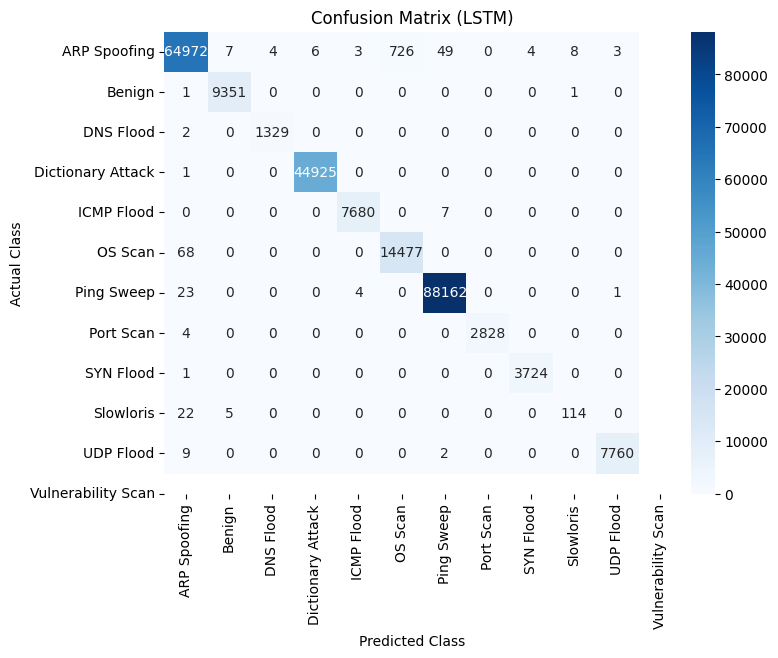

In [31]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test_original, y_pred_original)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_classes, yticklabels=unique_classes)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix (LSTM)')
plt.show()

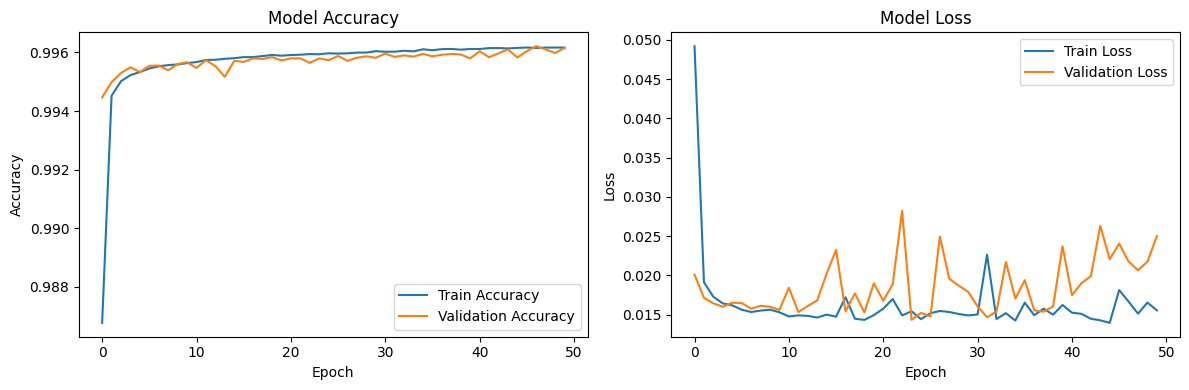

In [32]:
# --- 5. Optional: Plot Training History ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


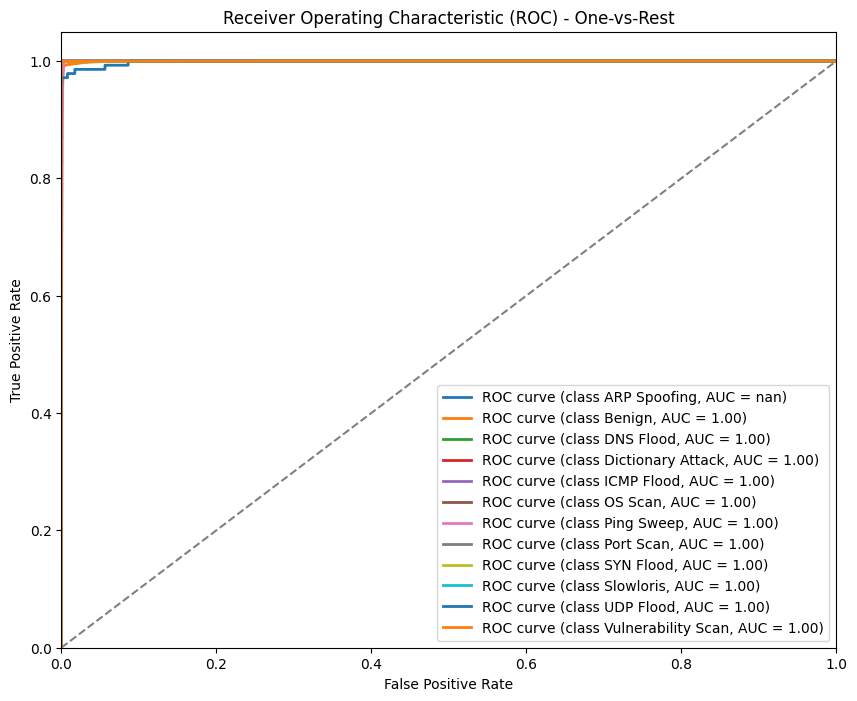

In [34]:
# --- 4. Plot AUC-ROC Curve (One-vs-Rest) ---
from sklearn.metrics import auc # Import the 'auc' function

plt.figure(figsize=(10, 8))
lw = 2

# Convert test labels to one-hot encoding for ROC calculation
y_test_onehot = to_categorical(label_encoder.transform(y_test_original), num_classes=num_classes)

for i, class_label in enumerate(unique_classes):
    fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=lw, label=f'ROC curve (class {class_label}, AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - One-vs-Rest')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
"""
Multiclass Prediction using LSTM with Custom CSV Dataset

This Jupyter Notebook demonstrates multiclass prediction using an LSTM model
with data loaded from a CSV file. The target column is assumed to have
more than 2 unique classes.

Assumptions about the CSV file:
    - It contains sequential data suitable for LSTM (e.g., time series).
    - One column is the 'target' column with more than 2 unique classes.
    - Non-numeric columns will be converted to numeric.
    - Data might need preprocessing for sequence learning (e.g., padding).
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- 1. Load and Preprocess Custom Dataset ---
csv_file_path = 'your_multiclass_dataset.csv'  # Replace with the actual path

try:
    df = pd.read_csv(csv_file_path)
    print(f"Dataset loaded successfully from {csv_file_path}")
except FileNotFoundError:
    print(f"Error: CSV file not found at {csv_file_path}")
    exit()

# Identify the target column
target_column = 'target'
if target_column not in df.columns:
    print(f"Error: Target column '{target_column}' not found.")
    exit()

y_original = df[target_column].values
X = df.drop(columns=[target_column])

# Convert all non-numeric columns to numeric
for column in X.columns:
    if pd.api.types.is_object_dtype(X[column]):
        try:
            X[column] = pd.to_numeric(X[column], errors='raise')
        except ValueError:
            print(f"Converting non-numeric column: {column}")
            le = LabelEncoder()
            X[column] = le.fit_transform(X[column])
    elif not pd.api.types.is_numeric_dtype(X[column]):
        print(f"Warning: Column '{column}' is not numeric and not string. Handling needed.")

X = X.values  # Convert features to numpy array

# --- 2. Prepare Data for LSTM ---
# Assuming your data is already in a sequential format or can be reshaped.
# LSTM expects input in the shape (samples, time steps, features).

# Determine the number of unique classes in the target variable
unique_classes = np.unique(y_original)
num_classes = len(unique_classes)
print(f"Number of unique classes in the target: {num_classes}")

# Encode the target variable to numerical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_original)

# Convert integer labels to one-hot encoded vectors
y_categorical = to_categorical(y_encoded, num_classes=num_classes)

# Reshape input data for LSTM if it's not already sequential
# Example: If each row is a time step and you have multiple features
n_samples = X.shape[0]
n_features = X.shape[1]
n_time_steps = 1  # Assuming each row is one time step
X_reshaped = X.reshape(n_samples, n_time_steps, n_features)

# Split data into training and testing sets
X_train, X_test, y_train_cat, y_test_cat, y_train_encoded, y_test_encoded, y_train_original, y_test_original = train_test_split(
    X_reshaped, y_categorical, y_encoded, y_original, test_size=0.2, random_state=42
)

# Scale the input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

# --- 3. Build and Train the LSTM Model ---
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(n_time_steps, n_features)))
model.add(Dense(num_classes, activation='softmax'))  # Softmax for multiclass

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

epochs = 50
batch_size = 32

history = model.fit(X_train_scaled, y_train_cat, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)

# --- 4. Evaluate the Model ---
y_pred_prob = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_pred_original = label_encoder.inverse_transform(y_pred_classes)

print("\n--- Classification Report ---")
print(classification_report(y_test_original, y_pred_original))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_original, y_pred_original)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_classes, yticklabels=unique_classes)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix (LSTM)')
plt.show()

# --- 5. Optional: Plot Training History ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()